# PC1 loadings for batting, bowling and fielding

This notebook shows what each discipline's first principal component is actually made of, which is how I interpreted the latent skill scores in the main pipeline (e.g. batting PC1 as a "scoring productivity" axis). Player and club names in the data have been anonymised.

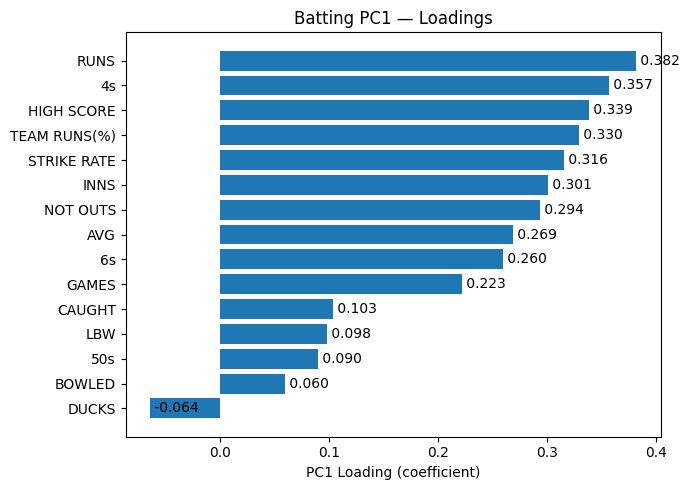

[Saved] ../figures/batting_pc1.png


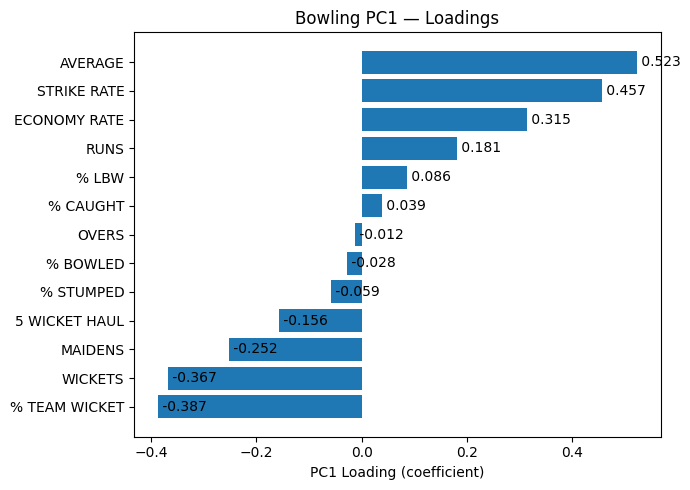

[Saved] ../figures/bowling_pc1.png


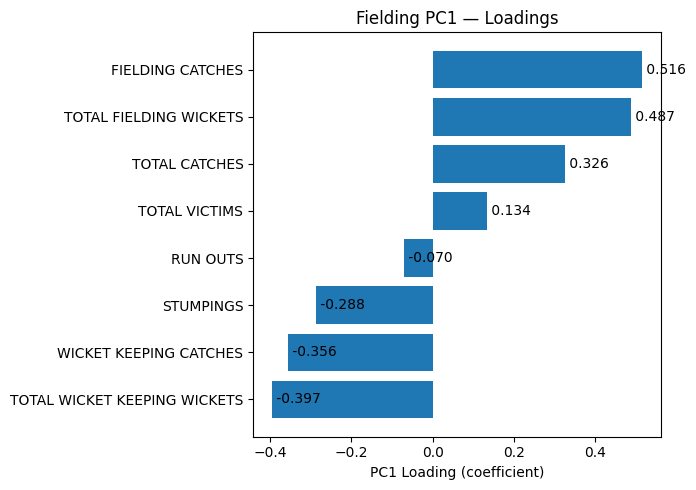

[Saved] ../figures/fielding_pc1.png
[Saved] Full loadings to ../outputs/pc1_loadings/*.csv


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path

BAT_PATH = "../data/batting_statistics.csv"
BOWL_PATH = "../data/bowling_statistics.csv"
FIELD_PATH = "../data/fielding_statistics.csv"

# Columns to exclude from analysis 
ID_LIKE_COLS = {
    "player", "name", "player_name", "club", "team", "rank", 
    "Player", "Club", "Rank", "Team"  # cover common capitalisations
}

def load_numeric_block(path: str) -> pd.DataFrame:
    # Load a CSV and return numeric-only performance columns
    df = pd.read_csv(path)
    # Drop obvious ID/non-performance columns if present
    drop_cols = [c for c in df.columns if c in ID_LIKE_COLS]
    df = df.drop(columns=drop_cols, errors="ignore")

    # Coerce everything left to numeric; string stats become NaN -> 0
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)
    # Drop all-zero columns (no signal)
    nonzero = df.columns[(df != 0).any(axis=0)]
    return df[nonzero].copy()

def pc1_loadings(df: pd.DataFrame) -> pd.Series:
    # Standardise features, run PCA(n_components=1), and return the loadings
    # (the eigenvector for PC1) as a pandas Series indexed by feature name.
    if df.shape[1] == 0:
        return pd.Series(dtype=float)

    Xz = StandardScaler().fit_transform(df.values)
    pca = PCA(n_components=1, random_state=42)
    pca.fit(Xz)
    # components_[0] are the PC1 coefficients aligned to standardized features
    load = pd.Series(pca.components_[0], index=df.columns)

    # Sort by absolute contribution (largest drivers first)
    load = load.reindex(load.abs().sort_values(ascending=False).index)
    return load

def plot_top5(loadings: pd.Series, title: str, filename: str):
    # Plot the Top-5 absolute loadings as a horizontal bar chart
    # Later edited to show the full loadings for each diciplie
    if loadings.empty:
        print(f"[WARN] No loadings for {title} (empty feature block).")
        return

    top5 = loadings.iloc[:15].sort_values()  # ascending for nicer barh ordering

    plt.figure(figsize=(7, 5))
    plt.barh(top5.index, top5.values)  # no color/style specified (per requirement)
    plt.xlabel("PC1 Loading (coefficient)")
    plt.title(title)
    # Annotate bars with numeric values
    for v, (y, name) in zip(top5.values, enumerate(top5.index)):
        plt.text(v, y, f" {v:.3f}", va="center")
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()
    print(f"[Saved] {filename}")

bat_df   = load_numeric_block(BAT_PATH)
bowl_df  = load_numeric_block(BOWL_PATH)
field_df = load_numeric_block(FIELD_PATH)

bat_load = pc1_loadings(bat_df)
bowl_load = pc1_loadings(bowl_df)
field_load = pc1_loadings(field_df)

plot_top5(bat_load,   "Batting PC1 — Loadings",   "../figures/batting_pc1.png")
plot_top5(bowl_load,  "Bowling PC1 — Loadings",   "../figures/bowling_pc1.png")
plot_top5(field_load, "Fielding PC1 — Loadings",  "../figures/fielding_pc1.png")

# Save full loadings tables
Path("../outputs/pc1_loadings").mkdir(parents=True, exist_ok=True)
bat_load.to_csv("../outputs/pc1_loadings/batting_pc1_loadings.csv")
bowl_load.to_csv("../outputs/pc1_loadings/bowling_pc1_loadings.csv")
field_load.to_csv("../outputs/pc1_loadings/fielding_pc1_loadings.csv")
print("[Saved] Full loadings to ../outputs/pc1_loadings/*.csv")
